# Evaluation

Test set metrics for both CNNs and issue classifiers.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import *

from config import DATA_DIR, MODELS_DIR, IMG_SIZE
from ml.model import MobileNetV2Quality, QualityCNN
from ml.features import extract_features, ImageFeatures
from ml.synthetic_data import ISSUE_TYPES

DEVICE = "cpu"
DATA_GEN = DATA_DIR / "generated"

## Load models and test data

In [2]:
class QualityDataset(Dataset):
    def __init__(self, split):
        self.img_dir = DATA_GEN / split / "images"
        self.meta = pd.read_csv(DATA_GEN / split / "metadata.csv")
    def __len__(self): return len(self.meta)
    def __getitem__(self, i):
        row = self.meta.iloc[i]
        img = cv2.imread(str(self.img_dir / row['filename']))
        if img is None: img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        t = torch.from_numpy((img[:,:,::-1].astype(np.float32)/255 - 0.5)/0.5).permute(2,0,1).contiguous()
        return t, torch.tensor(row['quality_score'], dtype=torch.float32)

test_ds = QualityDataset("test")
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
test_meta = pd.read_csv(DATA_GEN / "test" / "metadata.csv")

mobilenet = MobileNetV2Quality(pretrained=False)
mobilenet.load_state_dict(torch.load(MODELS_DIR / "mobilenet_quality.pt", map_location=DEVICE, weights_only=True))
mobilenet.eval()

cnn = QualityCNN()
cnn.load_state_dict(torch.load(MODELS_DIR / "cnn_quality.pt", map_location=DEVICE, weights_only=True))
cnn.eval()
print(f"Test set: {len(test_ds)} samples")

Test set: 9145 samples


## Regression metrics

In [3]:
def eval_regression(model, loader, name):
    preds, gts = [], []
    with torch.no_grad():
        for xb, yb in loader:
            p = model(xb).cpu().numpy()
            preds.extend(np.clip(p, 0, 100))
            gts.extend(yb.numpy())
    preds, gts = np.array(preds), np.array(gts)
    
    mae = mean_absolute_error(gts, preds)
    rmse = np.sqrt(mean_squared_error(gts, preds))
    r2 = r2_score(gts, preds)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")
    return preds, gts, {"mae": mae, "rmse": rmse, "r2": r2}

mob_preds, gts, mob_m = eval_regression(mobilenet, test_loader, "MobileNetV2")
cnn_preds, _, cnn_m = eval_regression(cnn, test_loader, "QualityCNN")

MobileNetV2: MAE=9.60, RMSE=13.54, R²=0.6902
QualityCNN: MAE=9.65, RMSE=13.19, R²=0.7060


## Predicted vs actual scatter

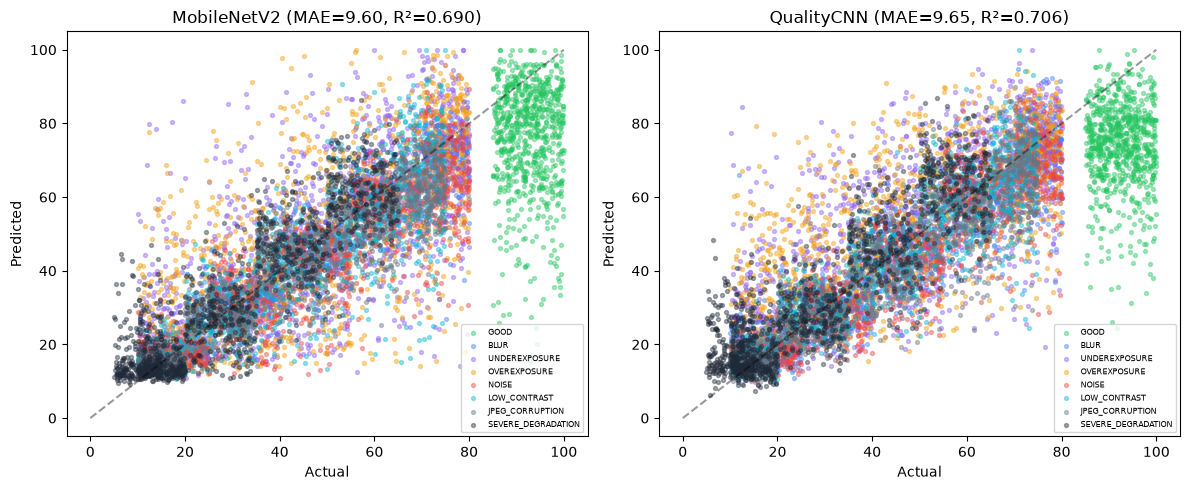

In [4]:
colors = {'GOOD': '#22c55e', 'BLUR': '#3b82f6', 'NOISE': '#ef4444', 'UNDEREXPOSURE': '#8b5cf6',
          'OVEREXPOSURE': '#f59e0b', 'LOW_CONTRAST': '#06b6d4', 'JPEG_CORRUPTION': '#6b7280',
          'SEVERE_DEGRADATION': '#1f2937'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, name, m in [(ax1, mob_preds, "MobileNetV2", mob_m), (ax2, cnn_preds, "QualityCNN", cnn_m)]:
    for dt in test_meta['degradation_type'].unique():
        mask = test_meta['degradation_type'] == dt
        ax.scatter(gts[mask], preds[mask], alpha=0.4, s=8, c=colors.get(dt, 'gray'), label=dt)
    ax.plot([0,100], [0,100], 'k--', alpha=0.4)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name} (MAE={m["mae"]:.2f}, R²={m["r2"]:.3f})')
    ax.legend(fontsize=6, loc='lower right')
plt.tight_layout()
plt.savefig(str(DATA_GEN / "regression_scatter.png"), dpi=150, bbox_inches='tight')
plt.show()

## MAE per degradation type

Model               MobileNetV2  QualityCNN
Type                                       
BLUR                       5.49        6.32
GOOD                      17.31       19.01
JPEG_CORRUPTION            6.69        6.97
LOW_CONTRAST               7.79        6.62
NOISE                      7.83        7.16
OVEREXPOSURE              14.10       13.27
SEVERE_DEGRADATION         7.15        8.32
UNDEREXPOSURE             13.46       13.16


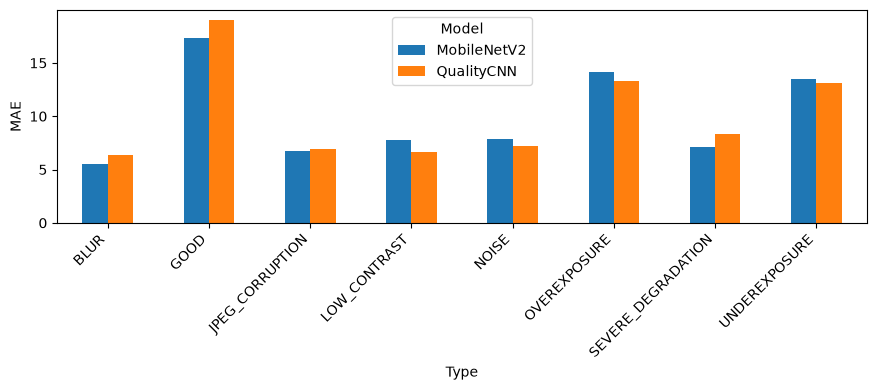

In [5]:
rows = []
for dt in test_meta['degradation_type'].unique():
    idx = np.where(test_meta['degradation_type'] == dt)[0]
    for name, p in [("MobileNetV2", mob_preds), ("QualityCNN", cnn_preds)]:
        rows.append({"Type": dt, "Model": name, "MAE": mean_absolute_error(gts[idx], p[idx])})

pivot = pd.DataFrame(rows).pivot(index="Type", columns="Model", values="MAE")
print(pivot.round(2))

pivot.plot(kind='bar', figsize=(9, 4))
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(DATA_GEN / "mae_by_type.png"), dpi=150, bbox_inches='tight')
plt.show()

## Issue classifier evaluation

In [6]:
with open(MODELS_DIR / "issue_classifiers.pkl", "rb") as f:
    classifiers = pickle.load(f)

feat_names = ImageFeatures.names()

# extract test features
X_test = []
for _, row in tqdm(test_meta.iterrows(), total=len(test_meta), desc="features"):
    img = cv2.imread(str(DATA_GEN / "test" / "images" / row['filename']))
    if img is None:
        X_test.append(np.zeros(len(feat_names)))
    else:
        X_test.append(extract_features(img).to_vector())
X_test = np.array(X_test)

features: 100%|██████████| 9145/9145 [00:36<00:00, 247.79it/s]


[blur] acc=0.873 f1=0.777 auc=0.939
[underexposure] acc=0.868 f1=0.633 auc=0.949
[overexposure] acc=0.833 f1=0.572 auc=0.931
[noise] acc=0.867 f1=0.758 auc=0.923
[low_contrast] acc=0.966 f1=0.884 auc=0.994
[corruption] acc=0.738 f1=0.585 auc=0.803


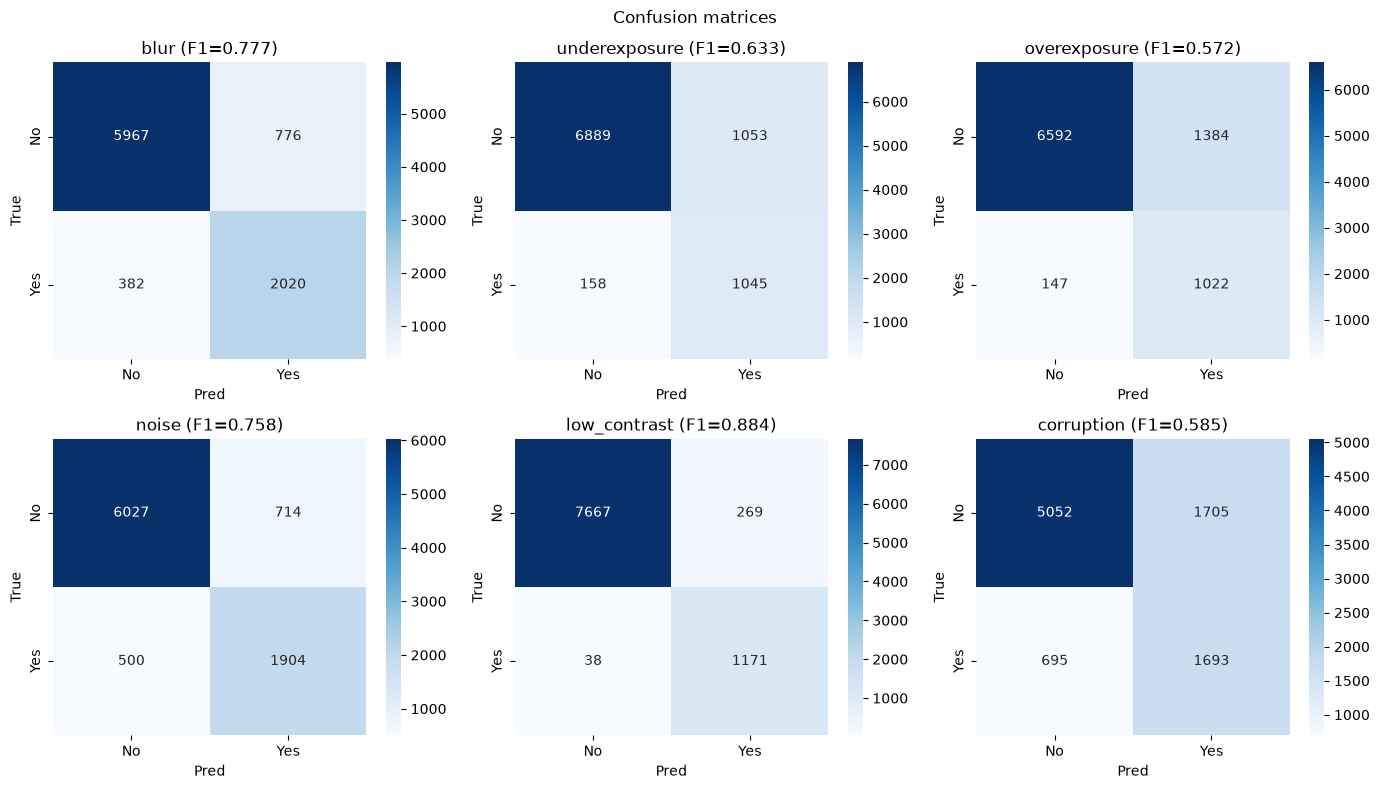

In [7]:
eval_results = {}
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, issue in enumerate(ISSUE_TYPES):
    if issue not in classifiers: continue
    
    y_true = test_meta[f'issue_{issue}'].values if f'issue_{issue}' in test_meta else np.zeros(len(test_meta))
    clf = classifiers[issue]
    Xs = clf["scaler"].transform(X_test)
    y_pred = clf["model"].predict(Xs)
    y_prob = clf["model"].predict_proba(Xs)[:, 1]
    
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"[{issue}] acc={acc:.3f} f1={f1:.3f} auc={f'{auc:.3f}' if auc else 'n/a'}")
    eval_results[issue] = {"accuracy": acc, "f1": f1, "roc_auc": auc, "cm": cm.tolist()}
    
    ax = axes.flatten()[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    ax.set_title(f'{issue} (F1={f1:.3f})')
    ax.set_xlabel('Pred')
    ax.set_ylabel('True')

plt.suptitle('Confusion matrices')
plt.tight_layout()
plt.savefig(str(DATA_GEN / "confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()

## ROC curves

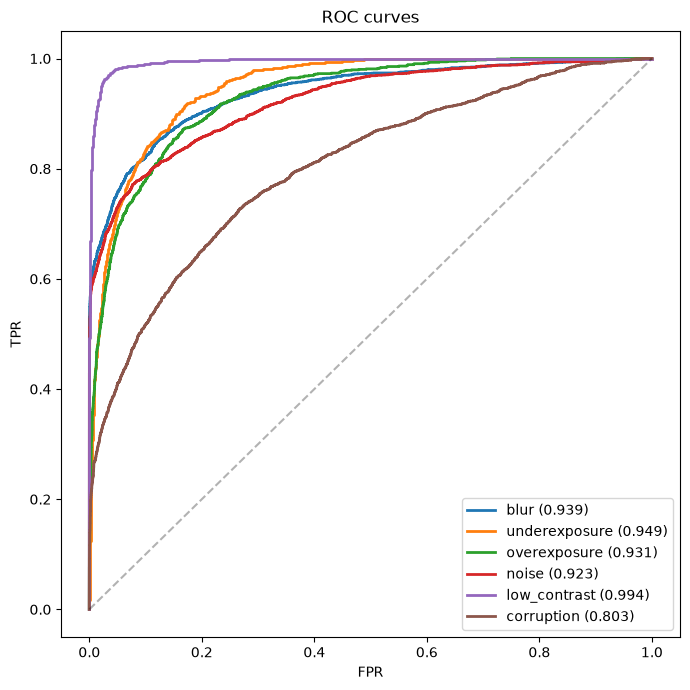

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))
for issue in ISSUE_TYPES:
    if issue not in classifiers: continue
    y_true = test_meta[f'issue_{issue}'].values if f'issue_{issue}' in test_meta else np.zeros(len(test_meta))
    if len(np.unique(y_true)) < 2: continue
    y_prob = classifiers[issue]["model"].predict_proba(classifiers[issue]["scaler"].transform(X_test))[:, 1]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{issue} ({roc_auc_score(y_true, y_prob):.3f})', lw=2)

ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC curves')
ax.legend()
plt.tight_layout()
plt.savefig(str(DATA_GEN / "roc_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

## Feature importance

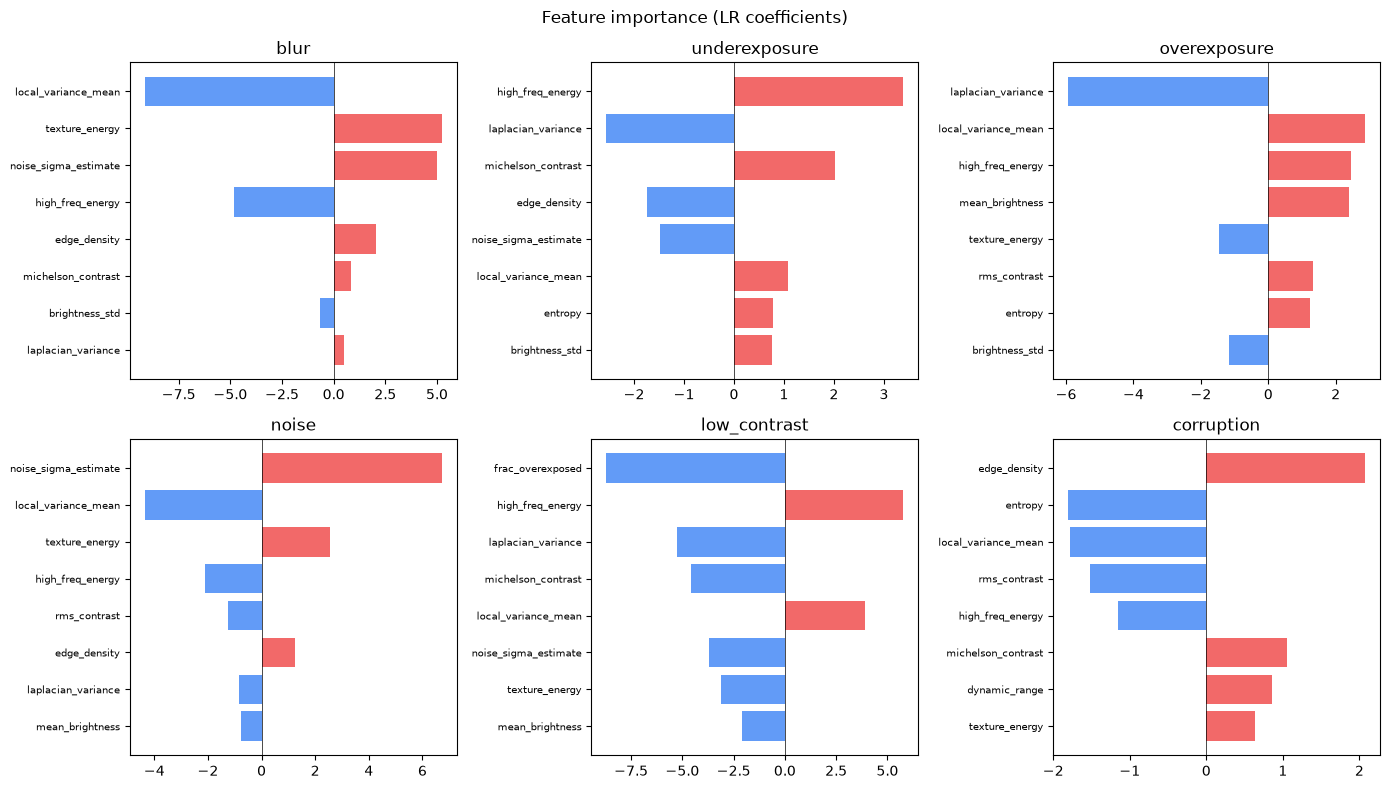

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for idx, issue in enumerate(ISSUE_TYPES):
    if issue not in classifiers: continue
    coefs = classifiers[issue]["model"].coef_[0]
    top = np.argsort(-np.abs(coefs))[:8]
    
    ax = axes.flatten()[idx]
    ax.barh(range(len(top)), [coefs[i] for i in top],
            color=['#ef4444' if coefs[i]>0 else '#3b82f6' for i in top], alpha=0.8)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([feat_names[i] for i in top], fontsize=7)
    ax.set_title(issue)
    ax.invert_yaxis()
    ax.axvline(0, color='black', lw=0.5)

plt.suptitle('Feature importance (LR coefficients)')
plt.tight_layout()
plt.savefig(str(DATA_GEN / "feature_importance.png"), dpi=150, bbox_inches='tight')
plt.show()

## Failure analysis — worst predictions

Worst 10 predictions (MobileNetV2):
  actual=93 pred=16 err=77 type=GOOD sev=0
  actual=94 pred=20 err=74 type=GOOD sev=0
  actual=94 pred=24 err=70 type=GOOD sev=0
  actual=12 pred=80 err=67 type=UNDEREXPOSURE sev=5
  actual=20 pred=86 err=66 type=UNDEREXPOSURE sev=5
  actual=99 pred=33 err=66 type=GOOD sev=0
  actual=93 pred=27 err=66 type=GOOD sev=0
  actual=12 pred=78 err=65 type=OVEREXPOSURE sev=5
  actual=14 pred=78 err=65 type=UNDEREXPOSURE sev=5
  actual=95 pred=31 err=64 type=GOOD sev=0


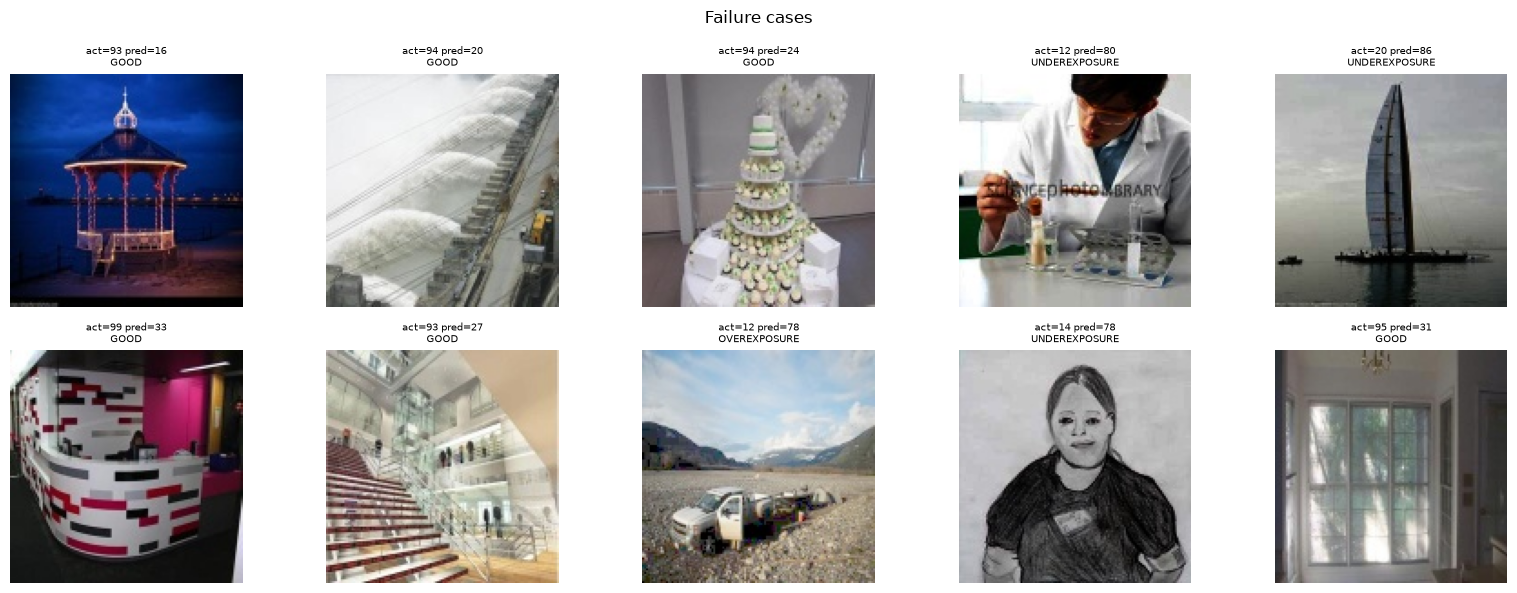

In [10]:
errors = np.abs(mob_preds - gts)
worst = np.argsort(-errors)[:10]

print("Worst 10 predictions (MobileNetV2):")
for i in worst:
    r = test_meta.iloc[i]
    print(f"  actual={gts[i]:.0f} pred={mob_preds[i]:.0f} err={errors[i]:.0f} type={r['degradation_type']} sev={r['severity']}")

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for i, idx in enumerate(worst):
    r = test_meta.iloc[idx]
    img = cv2.cvtColor(cv2.imread(str(DATA_GEN / "test" / "images" / r['filename'])), cv2.COLOR_BGR2RGB)
    axes.flatten()[i].imshow(img)
    axes.flatten()[i].set_title(f"act={gts[idx]:.0f} pred={mob_preds[idx]:.0f}\n{r['degradation_type']}", fontsize=7)
    axes.flatten()[i].axis('off')
plt.suptitle("Failure cases")
plt.tight_layout()
plt.savefig(str(DATA_GEN / "failure_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

## Known Limitations

- Only trained on synthetic degradations, real-world issues (motion blur, lens distortion) may differ
- Quality scores are synthetic, not from human perceptual ratings
- Single-label per image — real images can have multiple overlapping issues
- Trained on Places365 scenes only, may not generalize well to portraits/documents/medical images

In [11]:
report = {
    "test_size": len(test_ds),
    "regression": {
        "mobilenet": {k: round(float(v), 4) for k, v in mob_m.items()},
        "cnn": {k: round(float(v), 4) for k, v in cnn_m.items()},
    },
    "classifiers": {k: {kk: vv for kk, vv in v.items() if kk != 'cm'} for k, v in eval_results.items()},
}
with open(MODELS_DIR / "eval_report.json", "w") as f:
    json.dump(report, f, indent=2)
print(f"Saved eval report to {MODELS_DIR / 'eval_report.json'}")

Saved eval report to S:\IIIT Hydrabad\models\eval_report.json
